In [1]:
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import zipfile
import time

Test envoie mail

Fonction qui récupère toutes les photos à partir d'un dossart

In [2]:
def get_images_from_dossard(dossard: int):

    # parcours de toutes les galeries
    results_repertory = os.path.join('Results', '2025')
    galeries = [d for d in os.listdir(results_repertory) if os.path.isdir(os.path.join(results_repertory, d))]

    images_path = []

    for galerie in galeries:

        galerie_path = os.path.join(results_repertory, galerie)
        files = sorted([f for f in os.listdir(galerie_path) if f.lower().endswith("post_process.csv")])
        
        if len(files) > 0:
            file_name = files[0]
            file_path = os.path.join(galerie_path, file_name)

            df_result = pd.read_csv(file_path)

            # Vérifier dans toutes les colonnes Dossard_x si le dossard est présent
            mask = df_result.drop(columns=["file"]).eq(dossard).any(axis=1)

            # nom complet de l'image
            galerie_image_path = os.path.join('Images', '2025', galerie)
            matched_files = df_result.loc[mask, "file"].apply(lambda f: os.path.join(galerie_image_path, f)).tolist()
            images_path.extend(matched_files)

    return images_path

Images\2025\10 km Moulin bleu\IMG_4847.JPG


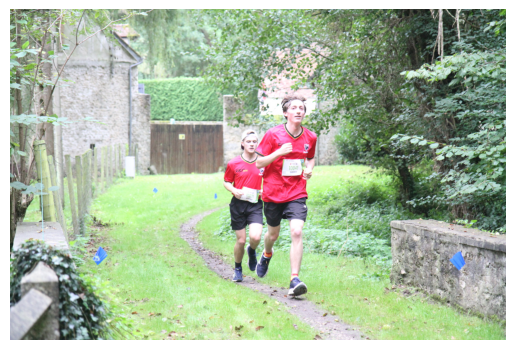

Images\2025\10 km Moulin bleu\IMG_4848.JPG


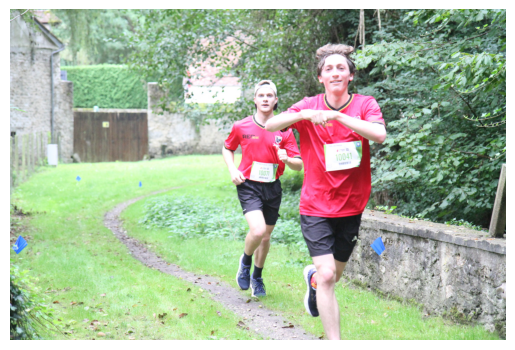

Images\2025\100EOS5D\MU8A9562.JPG


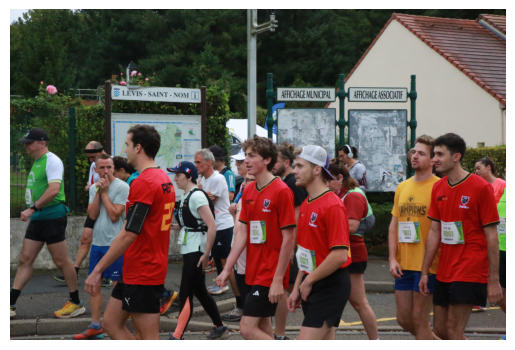

Images\2025\Autour de la course\IMG_4622.JPG


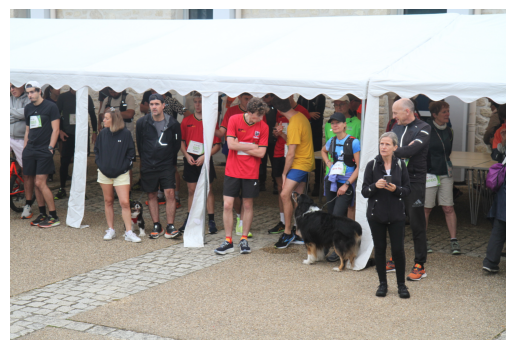

In [3]:
images_path = get_images_from_dossard(10071)


for image_path in images_path:
    print(image_path)

    image = mpimg.imread(image_path)

    if image is None: 
        print(f"Impossible de lire {images_path}")
        continue

    plt.imshow(image)
    plt.axis('off')  # Masquer les axes
    plt.show()

In [4]:
def create_zip_archive(images_list, output_zip_path):
    with zipfile.ZipFile(output_zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zipf:
        for img_path in images_list:
            zipf.write(img_path, arcname=os.path.basename(img_path))  # arcname = nom dans le zip
    return output_zip_path

In [5]:
MAX_EMAIL_SIZE = 20 * 1024 * 1024  # 20 Mo pour rester sous la limite Gmail

def write_and_send_email(email: str, dossard_photos_link: list, total_mail_count: int, subject_prefix="Trail des Sources de l'Yvette - Photos"):
    # Paramètres Gmail
    email_address = "tsy.levis78@gmail.com"

    # Découpage en mails selon la taille
    current_batch = []
    current_size = 0
    mail_count = 1
    total_mail_count += 1

    for img_path in dossard_photos_link:
        if not os.path.isfile(img_path):
            print(f"⚠️ Fichier non trouvé : {img_path}")
            continue

        file_size = os.path.getsize(img_path)
        # Si ajouter cette image dépasse la limite, envoyer le mail actuel et commencer un nouveau batch
        if current_size + file_size > MAX_EMAIL_SIZE and current_batch:
            send_email_batch(email_address, email, current_batch, subject_prefix, mail_count)
            mail_count += 1
            total_mail_count += 1
            current_batch = []
            current_size = 0

        current_batch.append(img_path)
        current_size += file_size

    # Envoyer le dernier batch
    if current_batch:
        send_email_batch(email_address, email, current_batch, subject_prefix, mail_count)

    return total_mail_count

def send_email_batch(sender_email, receiver_email, files_list, subject_prefix, batch_number):
    # Paramètres Gmail
    smtp_server = "smtp.gmail.com"
    smtp_port = 587
    # email_password = "rniv fhsg mlum hgpy"  # mot de passe lemerle.xavier@gmail.com
    email_password = "rtga qfvh jyhu llhh" # mdp tsy.levis78@gmail.com

    subject = f"{subject_prefix} ({batch_number})" if batch_number > 1 else subject_prefix
    body = "Bonjour,\n\n"
    if batch_number == 1:
        body_html = """
        Bonjour, \n\n

        <p>Nous avons le plaisir de vous adresser ce(s) quelque(s) photo(s) de vous prises lors de notre
        6ème édition du Trail des Sources de l’Yvette.
        Vous pouvez aussi découvrir d’autre photos de l’édition dans la rubrique 
        <a href='https://www.tsy-levis78.fr/galerie-photos2025'>Galerie photos 2025 | TSY Trail des Sources de l'Yvette</a> de notre site.</p>

        <p>Merci encore pour votre participation. Nous vous disons à l’année prochaine, le dimanche 20 septembre 2026.</p>

        <p>Les TSYlers</p>

        <p>PS : la reconnaissance de votre dossard ayant été faite par algorithme, merci par avance pour votre compréhension en cas d’erreur.</p>
        """
    else:
        body_html = """ 
        Bonjour, \n\n
        <p>La suite des images de votre dossard :</p>
        """

    msg = MIMEMultipart()
    msg["From"] = sender_email
    msg["To"] = receiver_email
    msg["Subject"] = subject
    msg.attach(MIMEText(body_html, "html"))


    # Ajouter les fichiers
    for filename in files_list:
        with open(filename, "rb") as f:
            part = MIMEBase("application", "octet-stream")
            part.set_payload(f.read())
            encoders.encode_base64(part)
            part.add_header(
                "Content-Disposition",
                f"attachment; filename={os.path.basename(filename)}"
            )
            msg.attach(part)

    # Envoi via Gmail
    with smtplib.SMTP(smtp_server, smtp_port) as server:
        server.starttls()
        server.login(sender_email, email_password)
        server.send_message(msg)

    print(f"📩 Mail envoyé avec succès ! Batch {batch_number}, {len(files_list)} fichiers.")


In [6]:
def send_mail_to_everyone(year='2025', start=None, end=None, total_mail_count=0): 
    
    # parcours de toutes les galeries
    results_repertory = os.path.join('Results', year)

    # Lecture du fichier correspondance dossard - email
    dossard_email_file_name = "dossard_email.csv"
    dossard_email_file_path = os.path.join(results_repertory, dossard_email_file_name)

    df_dossard_email = pd.read_csv(
        dossard_email_file_path,
        sep=';',                # séparateur point-virgule
        encoding='latin1'       # ou 'iso-8859-1' (équivalent)
    )

    if not start:
        start = 0
    if not end:
        end = len(df_dossard_email)

    # Couples prénom/nom à ignorer (tout en minuscule)
    skip_list = {
        ("martin", "donze"),
        ("antonio", "godoy pellini"),
        ("fabien", "michel"),
        ("martin", "halbourg")
    }

    # parcours de chaque ligne entre start et end
    for idx, row in df_dossard_email.iloc[start:end].iterrows():
        
        # info de la personne
        mail = row["Mail"]
        prenom = row["Prenom"].lower()
        nom = row["Nom"].lower()
        dossard_str = row["Dossard"]

        if (prenom, nom) in skip_list:
            print(f"⏭️ Mail ignoré pour {prenom.title()} {nom.title()} (dossard {dossard_str})")
            continue

        if pd.isna(mail) or str(mail).strip() == "":
            print(f"Pas de mail renseigné pour dossard {dossard_str}")
            continue

        # conversion du dossart en int
        try:
            dossard = int(dossard_str)
        except ValueError:
            print(f"⚠️ Dossard invalide à la ligne {idx} : {dossard_str}")
            continue

        # récupération des photos associés
        dossard_photos_link = get_images_from_dossard(dossard)

        # envoie des mails 
        if len(dossard_photos_link) >= 1:
            print(f"Dossard {dossard}, envoie de(s) {len(dossard_photos_link)} photo(s) à {mail}...")
            total_mail_count = write_and_send_email(mail, dossard_photos_link, total_mail_count)
            print(f"Nombre total de mail envoyés : {total_mail_count} (index {idx})")

            # pause de 10sec
            time.sleep(10)
        else: 
            print(f"Dossard {dossard}, pas de photo trouvée.")

    return total_mail_count



total_mail_count = send_mail_to_everyone(year="2025", start=400, end=None, total_mail_count=600)

Dossard 21260, envoie de(s) 2 photo(s) à aude_8587@hotmail.com...
📩 Mail envoyé avec succès ! Batch 1, 2 fichiers.
Nombre total de mail envoyés : 601 (index 400)
Dossard 21053, envoie de(s) 5 photo(s) à sche44@gmail.com...
📩 Mail envoyé avec succès ! Batch 1, 4 fichiers.
📩 Mail envoyé avec succès ! Batch 2, 1 fichiers.
Nombre total de mail envoyés : 603 (index 401)
Dossard 21171, envoie de(s) 4 photo(s) à merletvalerie@yahoo.fr...
📩 Mail envoyé avec succès ! Batch 1, 3 fichiers.
📩 Mail envoyé avec succès ! Batch 2, 1 fichiers.
Nombre total de mail envoyés : 605 (index 402)
Dossard 21198, envoie de(s) 12 photo(s) à magali.perez.mp@gmail.com...
📩 Mail envoyé avec succès ! Batch 1, 3 fichiers.
📩 Mail envoyé avec succès ! Batch 2, 2 fichiers.
📩 Mail envoyé avec succès ! Batch 3, 7 fichiers.
Nombre total de mail envoyés : 608 (index 403)
Dossard 21202, envoie de(s) 7 photo(s) à pescheludovic@hotmail.com...
📩 Mail envoyé avec succès ! Batch 1, 1 fichiers.
📩 Mail envoyé avec succès ! Batch 2,